In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'axes.linewidth': 0.8,
})

df = pd.read_csv('sweep_results.csv')
df = df[df['avg_remote_reads_per_batch'] != 'timeout']
df['avg_remote_reads_per_batch'] = df['avg_remote_reads_per_batch'].astype(float)
df.head()

,seed,scheduler,tx_size_dist,cross_shard_prob,overlap_prob,zipf_alpha,avg_remote_reads_per_batch,avg_runtime_per_batch_s
0,0,best_program,light,0.25,0.0,0.8,1152.2,0.001482
1,0,paper,light,0.25,0.0,0.8,1136.8,1.352099
2,0,best_program,light,0.25,0.0,1.2,1355.0,0.001217
3,0,paper,light,0.25,0.0,1.2,896.4,1.356830
4,0,best_program,light,0.25,0.3,0.8,1198.0,0.001459


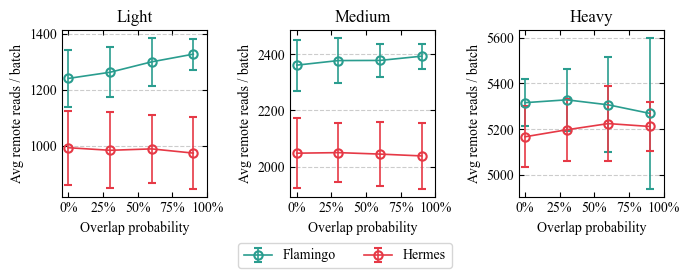

In [5]:
# Aggregate across seeds: mean ± std grouped by scheduler + overlap_prob
overlap_agg = (
    df.groupby(['scheduler', 'tx_size_dist', 'overlap_prob'])['avg_remote_reads_per_batch']
    .agg(['mean', 'std'])
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(7, 2.8), sharey=False)
tx_sizes = ['light', 'medium', 'heavy']
colors = {'best_program': '#2a9d8f', 'paper': '#e63946'}
labels = {'best_program': 'Flamingo', 'paper': 'Hermes'}

for ax, tx in zip(axes, tx_sizes):
    sub = overlap_agg[overlap_agg['tx_size_dist'] == tx]
    for sched in ['best_program', 'paper']:
        s = sub[sub['scheduler'] == sched].sort_values('overlap_prob')
        ax.errorbar(s['overlap_prob'], s['mean'], yerr=s['std'],
                    marker='o', capsize=3, color=colors[sched], label=labels[sched],
                    markerfacecolor='none', markeredgewidth=1.5, linewidth=1.2)
    ax.set_title(tx.capitalize())
    ax.set_xlabel('Overlap probability')
    ax.set_ylabel('Avg remote reads / batch')
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#aaaaaa')
    ax.set_axisbelow(True)
    ax.tick_params(which='both', direction='in', top=True, right=True)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, 0), bbox_transform=fig.transFigure)
plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.savefig('sweep_routing_quality_overlap.png', dpi=300, bbox_inches='tight')
plt.savefig('sweep_routing_quality_overlap.pdf', bbox_inches='tight')
plt.show()

In [6]:
# # Aggregate across seeds: mean ± std grouped by scheduler + cross_shard_prob
# csp_agg = (
#     df.groupby(['scheduler', 'tx_size_dist', 'cross_shard_prob'])['avg_remote_reads_per_batch']
#     .agg(['mean', 'std'])
#     .reset_index()
# )

# fig, axes = plt.subplots(1, 3, figsize=(7, 2.8), sharey=False)

# for ax, tx in zip(axes, tx_sizes):
#     sub = csp_agg[csp_agg['tx_size_dist'] == tx]
#     for sched in ['best_program', 'paper']:
#         s = sub[sub['scheduler'] == sched].sort_values('cross_shard_prob')
#         ax.errorbar(s['cross_shard_prob'], s['mean'], yerr=s['std'],
#                     marker='o', capsize=3, color=colors[sched], label=labels[sched],
#                     markerfacecolor='none', markeredgewidth=1.5, linewidth=1.2)
#     ax.set_title(tx.capitalize())
#     ax.set_xlabel('Cross-shard probability')
#     ax.set_ylabel('Avg remote reads / batch')
#     ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
#     ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#aaaaaa')
#     ax.set_axisbelow(True)
#     ax.tick_params(which='both', direction='in', top=True, right=True)

# handles, legend_labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, legend_labels, loc='lower center', ncol=2,
#            bbox_to_anchor=(0.5, 0), bbox_transform=fig.transFigure)
# plt.tight_layout()
# plt.subplots_adjust(bottom=0.28)
# plt.savefig('sweep_routing_quality_crossshard.png', dpi=300, bbox_inches='tight')
# plt.savefig('sweep_routing_quality_crossshard.pdf', bbox_inches='tight')
# plt.show()